In [5]:
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import chi2_contingency
# # import math
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import r2_score 
from sklearn.ensemble import RandomForestRegressor
# from sklearn.preprocessing import LabelEncoder
import ModelFunctions



In [6]:

data = pd.read_csv("data_pre_process.csv")

Xtrain_fso, Xval_fso, Xtest_fso, Ytrain_fso, Yval_fso, Ytest_fso = \
    ModelFunctions.split_data(data, "FSO_Att",drop_column = ["Frequency",'RFL_Att']) # Frequency doesn't relate to FSO_Att

Xtrain_rfl, Xval_rfl, Xtest_rfl, Ytrain_rfl, Yval_rfl, Ytest_rfl = \
    ModelFunctions.split_data(data, "RFL_Att",drop_column = ['FSO_Att'])


#######  FSO_Att Data Set  ######
FSO_Att Training set feature count: (63965, 24)
FSO_Att Validation set feature count: (13707, 24)
FSO_Att Training set label count: (63965,)
FSO_Att Validation set label count: (13707,)
#######  RFL_Att Data Set  ######
RFL_Att Training set feature count: (63965, 25)
RFL_Att Validation set feature count: (13707, 25)
RFL_Att Training set label count: (63965,)
RFL_Att Validation set label count: (13707,)


# Estimators tunning for FSO
Based on single Decision Tree Analysis 
"max_depth":[18],'min_samples_leaf':[9],'min_samples_split':[3] is the optimized hyperparameter in a tree, 
and based on above parameter to tunning random forest n_estimator

# FSO coarse tuning

In [ ]:
# file is two parts, which need to pd.concat 
parameters = {
    'n_estimators': [*range(60,301,10)],
    'max_depth': [*range(15,31,5)],
    'min_samples_leaf': [4,5,6,7],
    'min_samples_split': [3]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_fso, 
                            Ytrain_fso, 
                            Xval_fso, 
                            Yval_fso,
                            n_jobs = 4)
ModelFunctions.save_model_results(results, parameters, file_model="_RF", file_att="_FSO")

# df1 = pd.read_csv("results_202402222107_n_estimators-100-300-11_max_depth-15-30-4_min_samples_leaf-4-7-4_min_samples_split-3-3-1_RFFSO.csv")
# df2 = pd.read_csv("results_202402232258_n_estimators-60-80-2_max_depth-15-30-4_min_samples_leaf-4-7-4_min_samples_split-3-3-1_RF_fso_compensate.csv")

# FSO fine tuning

In [30]:
parameters = {
    'n_estimators': [*range(120,150,10)],
    'max_depth': [*range(27,33,1)],
    'min_samples_leaf': [1,2,3,4],
    'min_samples_split': [2,3]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_fso, 
                            Ytrain_fso, 
                            Xval_fso, 
                            Yval_fso,
                            n_jobs = 4)
ModelFunctions.save_model_results(results, parameters, file_model="_RF", file_att="_FSO")
# df1 = pd.read_csv("results_202402230144_n_estimators-120-140-3_max_depth-27-32-6_min_samples_leaf-2-5-4_min_samples_split-2-3-2_RFFSO.csv")
# df2 = pd.read_csv('results_202402240942_n_estimators-120-140-3_max_depth-28-32-3_min_samples_leaf-1-1-1_min_samples_split-2-3-2_RF_FSO_compensate.csv')


train Best parameters: None
train Best score: inf
valid Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 140}
valid Best score: 0.6939928895942131
Results saved to results_202402240942_n_estimators-120-140-3_max_depth-28-32-3_min_samples_leaf-1-1-1_min_samples_split-2-3-2_RF_FSO_compensate.csv


'results_202402240942_n_estimators-120-140-3_max_depth-28-32-3_min_samples_leaf-1-1-1_min_samples_split-2-3-2_RF_FSO_compensate.pkl'

# Estimators tunning for RFL
Based on single Decision Tree Analysis 
"max_depth":[20],'min_samples_leaf':[6],'min_samples_split':[3] is the most optimized parameters, and based on above parameters to operate RFL tunning 

In [17]:

parameters = {
    'n_estimators': [*range(60,301,20)],
    'max_depth': [15,20,25,30],
    'min_samples_leaf': [4,5,6,7],
    'min_samples_split': [3]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_rfl, 
                            Ytrain_rfl, 
                            Xval_rfl, 
                            Yval_rfl,
                            n_jobs = 4)
ModelFunctions.save_model_results(results, parameters, file_model="_RF", file_att="_RFL")

# df1 = pd.read_csv("results_202402231350_n_estimators-100-300-11_max_depth-15-30-4_min_samples_leaf-4-7-4_min_samples_split-3-3-1_RF_RFL.csv")
# df2 = pd.read_csv("results_202402232230_n_estimators-60-80-2_max_depth-15-30-4_min_samples_leaf-4-7-4_min_samples_split-3-3-1_RF_rfl_compensate.csv")

train Best parameters: {'max_depth': 30, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 300}
train Best score: 0.1096422937562162
valid Best parameters: {'max_depth': 25, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 100}
valid Best score: 0.3192357673956129


# RFL fine tunning
based on the coarse tunning, n_estimator = 100, max-depth = 25， min_leaf_sample=4 min_split_number= 3 

In [27]:
parameters = {
    'n_estimators': [*range(100,141,10)],
    'max_depth': [23,24,25,26,27,28],
    'min_samples_leaf': [1,2,3,4],
    'min_samples_split': [2,3]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_rfl, 
                            Ytrain_rfl, 
                            Xval_rfl, 
                            Yval_rfl,
                            n_jobs = 4)
ModelFunctions.save_model_results(results, parameters, file_model="_RF", file_att="_RFL")

train Best parameters: {'max_depth': 28, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 140}
train Best score: 0.03925189332479551
valid Best parameters: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 130}
valid Best score: 0.2800648823607526


# RF model best performance 

In [8]:
parameters = {
    'n_estimators': [130],
    'max_depth': [30],
    'min_samples_leaf': [1],
    'min_samples_split': [2]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_fso, 
                            Ytrain_fso, 
                            Xval_fso, 
                            Yval_fso,
                            n_jobs = 4)
print("*********fso_val***************")
print(results)
print("************************")
parameters = {
    'n_estimators': [130],
    'max_depth': [30],
    'min_samples_leaf': [1],
    'min_samples_split': [2]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_fso, 
                            Ytrain_fso, 
                            Xtest_fso, 
                            Ytest_fso,
                            n_jobs = 4)
print("*********fso_test***************")
print(results)
print("************************")

parameters = {
    'n_estimators': [110],
    'max_depth': [28],
    'min_samples_leaf': [1],
    'min_samples_split': [2]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_rfl, 
                            Ytrain_rfl, 
                            Xval_rfl, 
                            Yval_rfl,
                            n_jobs = 4)
print("*********rfl_val***************")
print(results)
print("************************")

parameters = {
    'n_estimators': [110],
    'max_depth': [28],
    'min_samples_leaf': [1],
    'min_samples_split': [2]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_rfl, 
                            Ytrain_rfl, 
                            Xtest_rfl, 
                            Ytest_rfl,
                            n_jobs = 4)
print("*********rfl_test***************")
print(results)
print("************************")



train Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 130}
train Best score: 0.09743382906320416
valid Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 130}
valid Best score: 0.6940498602039414
*********fso_val***************
[{'params': {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 130}, 'train_mse': 0.09743382906320416, 'train_r2': 0.9936547708800652, 'val_mse': 0.6940498602039414, 'val_r2': 0.9538645838220653}]
************************
train Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 130}
train Best score: 0.09743382906320416
valid Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 130}
valid Best score: 0.6072213241085717
*********fso_test***************
[{'params': {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 130}

In [9]:
print(np.sqrt([0.097,0.69,0.61,0.039,0.29,0.25]))

[0.31144823 0.83066239 0.78102497 0.19748418 0.53851648 0.5       ]


Evaluate the feature importance of fso rf model

In [10]:
fso_rf_model = RandomForestRegressor(n_estimators = 130, max_depth=30, \
                                     min_samples_leaf = 1, random_state = 25,\
                                     min_samples_split =2, oob_score=True, n_jobs=6 )
# fso_rf_rmse = cross_val_score(fso_rf_model,Xtrain_fso,Ytrain_fso,cv = 2,scoring = "neg_mean_squared_error",n_jobs=-1)
# print('fso training set rmse:', np.sqrt(-fso_rf_rmse).mean())
# fso_rf_r2 = cross_val_score(fso_rf_model,Xtrain_fso,Ytrain_fso,cv = 2,scoring = "r2",n_jobs=-1)
# print('fso training set r2:', fso_rf_r2.mean())


Feature Importance: [0.02271067 0.00813117 0.00717366 0.34519937 0.02945277 0.02617726
 0.07396507 0.00169338 0.00152786 0.00147664 0.02449223 0.00214374
 0.08982336 0.01950955 0.02779869 0.03797571 0.01951771 0.13806395
 0.05139865 0.04930978 0.00247159 0.00502051 0.01017551 0.00479119]


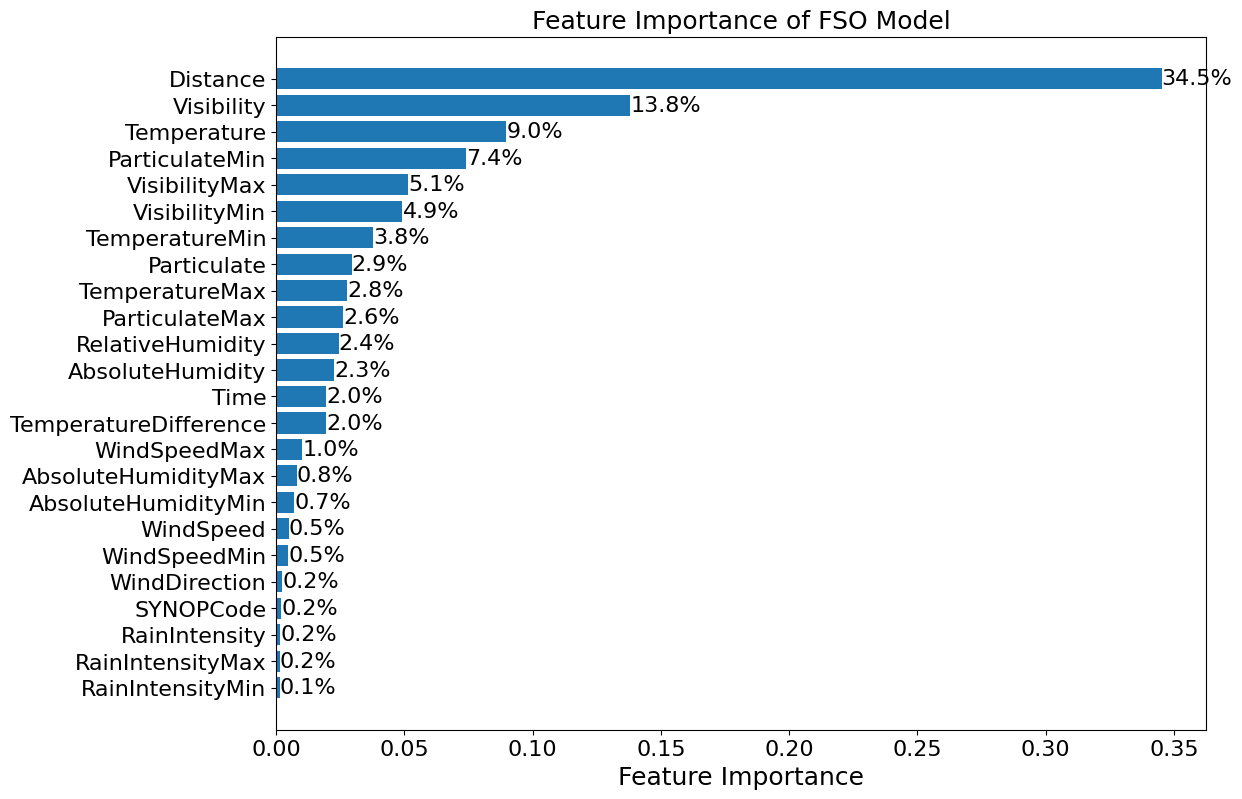

In [11]:
fso_rf_model.fit(Xtrain_fso, Ytrain_fso)

sorted_features_fso,sorted_importance_fso = \
    ModelFunctions.sort_features(fso_rf_model,Xtrain_fso,channel = "FSO",figure = False)

feature_importance = fso_rf_model.feature_importances_

print("Feature Importance:", feature_importance)

plt.figure(figsize=(12, 9))
bars = plt.barh(sorted_features_fso, sorted_importance_fso)
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width()*100:.1f}%', 
             va='center', ha='left', fontsize=16, color='black')

plt.xlabel('Feature Importance',fontsize=18)
#plt.ylabel('Features',fontsize=18)
plt.title('Feature Importance of FSO Model',fontsize=18)
plt.tick_params(axis='both', labelsize=16)
plt.show()

In [6]:
# # calculate SHAP 
# explainer = shap.TreeExplainer(fso_rf_model)
# shap_values = explainer.shap_values(Xtrain_fso)

# # SHAP visualization
# shap.summary_plot(shap_values, Xtrain_fso, feature_names=Xtrain_fso.columns)

Evaluate the feature importance of rfl rf model

In [12]:
rfl_rf_model = RandomForestRegressor(n_estimators = 110, max_depth=28, \
                                     min_samples_leaf = 1, random_state = 25,\
                                     min_samples_split = 2  )
# rfl_rf_rmse = cross_val_score(rfl_rf_model,Xtrain_rfl,Ytrain_rfl,cv = 2,scoring = "neg_mean_squared_error",n_jobs=-1)
# print('rfl training set rmse:', np.sqrt(-rfl_rf_rmse).mean())
# rfl_rf_r2 = cross_val_score(rfl_rf_model,Xtrain_rfl,Ytrain_rfl,cv = 2,scoring = "r2",n_jobs=-1)
# print('rfl training set r2:', rfl_rf_r2.mean())

Feature Importance: [0.20392269 0.00836114 0.00608916 0.20791753 0.0114239  0.00277842
 0.01651278 0.00705984 0.23551333 0.08941104 0.05356089 0.01473164
 0.02789504 0.05927209 0.00690615 0.00829586 0.00633503 0.0064267
 0.00955863 0.00527468 0.00702779 0.0010928  0.00105337 0.00262974
 0.00094977]


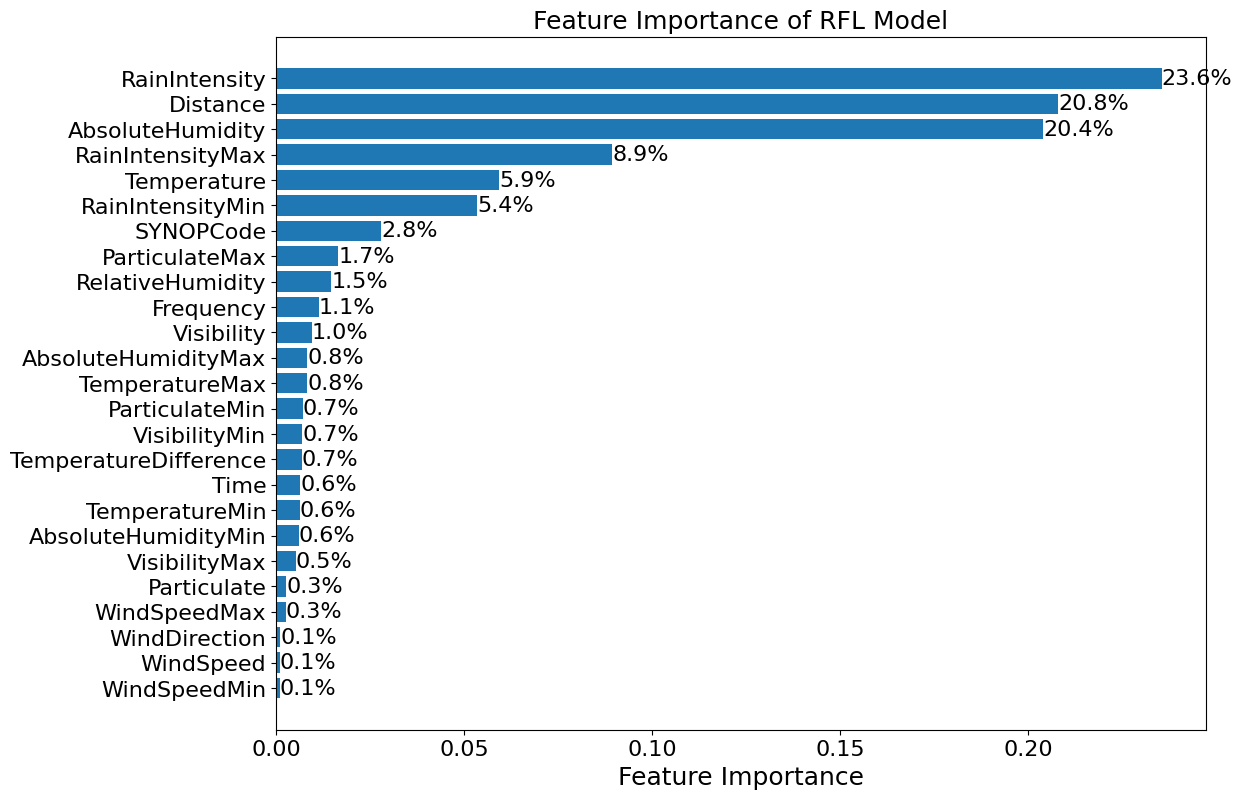

In [13]:
rfl_rf_model.fit(Xtrain_rfl, Ytrain_rfl)
feature_importance = rfl_rf_model.feature_importances_
print("Feature Importance:", feature_importance)

sorted_features_rfl,sorted_importance_rfl = \
    ModelFunctions.sort_features(rfl_rf_model,Xtrain_rfl,channel = "FSO",figure = False)


plt.figure(figsize=(12, 9))
bars = plt.barh(sorted_features_rfl, sorted_importance_rfl)

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width()*100:.1f}%', 
             va='center', ha='left', fontsize=16, color='black')

plt.xlabel('Feature Importance',fontsize=18)
#plt.ylabel('Features',fontsize=18)
plt.title('Feature Importance of RFL Model',fontsize=18)
plt.tick_params(axis='both', labelsize=16)
plt.show()

The wrapper method using out of bag information to determine the selection of feature 

In [ ]:
fso_rf_model = RandomForestRegressor(n_estimators = 130, max_depth=30, \
                                     min_samples_leaf = 1, random_state = 25,\
                                     min_samples_split =2, oob_score=True, n_jobs=6 )

performance_scores = ModelFunctions.wrapper_method (fso_rf_model,Xtrain_fso,Ytrain_fso,Xval_fso,Yval_fso,channel = "FSO")

important_columns = ["remove_feature", "train_rmse", "train_r2","val_rmse","val_r2", "oob_r2","next_remove","importance_score"]
df = pd.DataFrame(performance_scores, columns=important_columns)
file_name = "FSO_130-30-1-2_feature_importance_wrapple.csv"
df.to_csv(file_name, index=False)  



In [ ]:
rfl_rf_model = RandomForestRegressor(n_estimators = 130, max_depth=25, \
                                     min_samples_leaf = 1, random_state = 25,\
                                     min_samples_split = 2, oob_score=True,n_jobs=6  )
performance_scores = ModelFunctions.wrapper_method (rfl_rf_model,Xtrain_rfl,Ytrain_rfl,Xval_rfl,Yval_rfl,channel = "RFL")

important_columns = ["remove_feature", "train_rmse", "train_r2","val_rmse","val_r2", "oob_r2","next_remove","importance_score"]
df = pd.DataFrame(performance_scores, columns=important_columns)
file_name = "rfl_130-25-1-2_feature_importance_wrapple.csv"
df.to_csv(file_name, index=False)  

In [ ]:
# data['AbsoluteHumidityRange'] = data['AbsoluteHumidityMax']-data['AbsoluteHumidityMin']
# data['ParticulateRange'] = data['ParticulateMax'] - data['ParticulateMin']
# data['RainIntensityRange'] = data['RainIntensityMax'] - data['RainIntensityMin']
# data['TemperatureRange'] = data['TemperatureMax'] - data['TemperatureMin']
# data['VisibilityRange'] = data['VisibilityMax'] - data['VisibilityMin']
# data['WindSpeedRange'] = data['WindSpeedMax'] - data['WindSpeedMin']



# results_202402271050_n_estimators-120-150-4_max_depth-27-33-4_min_samples_leaf-1-2-2_min_samples_split-2-3-2_RF_FSO.csv

# Rebuilt model

In [ ]:
df = pd.read_csv("FSO_130-30-1-2_feature_importance_wrapple.csv")
fso_columns = df['remove_feature'][:-7]  
fso_columns = list(fso_columns)
fso_columns.remove("All Features")
fso_columns
Xtrain_fso, Xval_fso, Xtest_fso, Ytrain_fso, Yval_fso, Ytest_fso = \
    ModelFunctions.split_data(data, "FSO_Att",drop_column = fso_columns + ["Frequency",'RFL_Att'],\
                              test_size=0.2, valtest_available = 0, random_state=42) # Frequency doesn't relate to FSO_Att

# # Xtrain_rfl, Xval_rfl, Xtest_rfl, Ytrain_rfl, Yval_rfl, Ytest_rfl = \
# #     ModelFunctions.split_data(data, "RFL_Att",drop_column = fso_columns['FSO_Att'],\
# #                               test_size=0.15, valtest_available = 0, random_state=42)

#######  FSO_Att Data Set  ######
FSO_Att Training set feature count: (73103, 7)
FSO_Att Validation set feature count: (18276, 7)
FSO_Att Training set label count: (73103,)
FSO_Att Validation set label count: (18276,)


In [ ]:
parameters = {
    'n_estimators': [*range(120,361,20)],
    'max_depth': [*range(20,61,10)],
    'min_samples_leaf': [1],
    'min_samples_split': [2,10,50,100]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_fso, 
                            Ytrain_fso, 
                            Xval_fso, 
                            Yval_fso,
                            n_jobs = 6)
file_name_results = ModelFunctions.save_model_results(results, parameters, file_model="_RF_rebuilt_80%", file_att="_FSO")

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
train Best parameters: {'max_depth': 60, 'min_samples_leaf': 1, 'min

train_mse best:
     n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
168           360         50                 1                  2   0.094335   
220           360         60                 1                  2   0.094335   

     train_r2   val_mse    val_r2  
168  0.993857  0.689692  0.954154  
220  0.993857  0.689692  0.954154  
valid_mse best:
    n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
64           360         30                 1                  2   0.094701   

    train_r2   val_mse    val_r2  
64  0.993833  0.689099  0.954194  


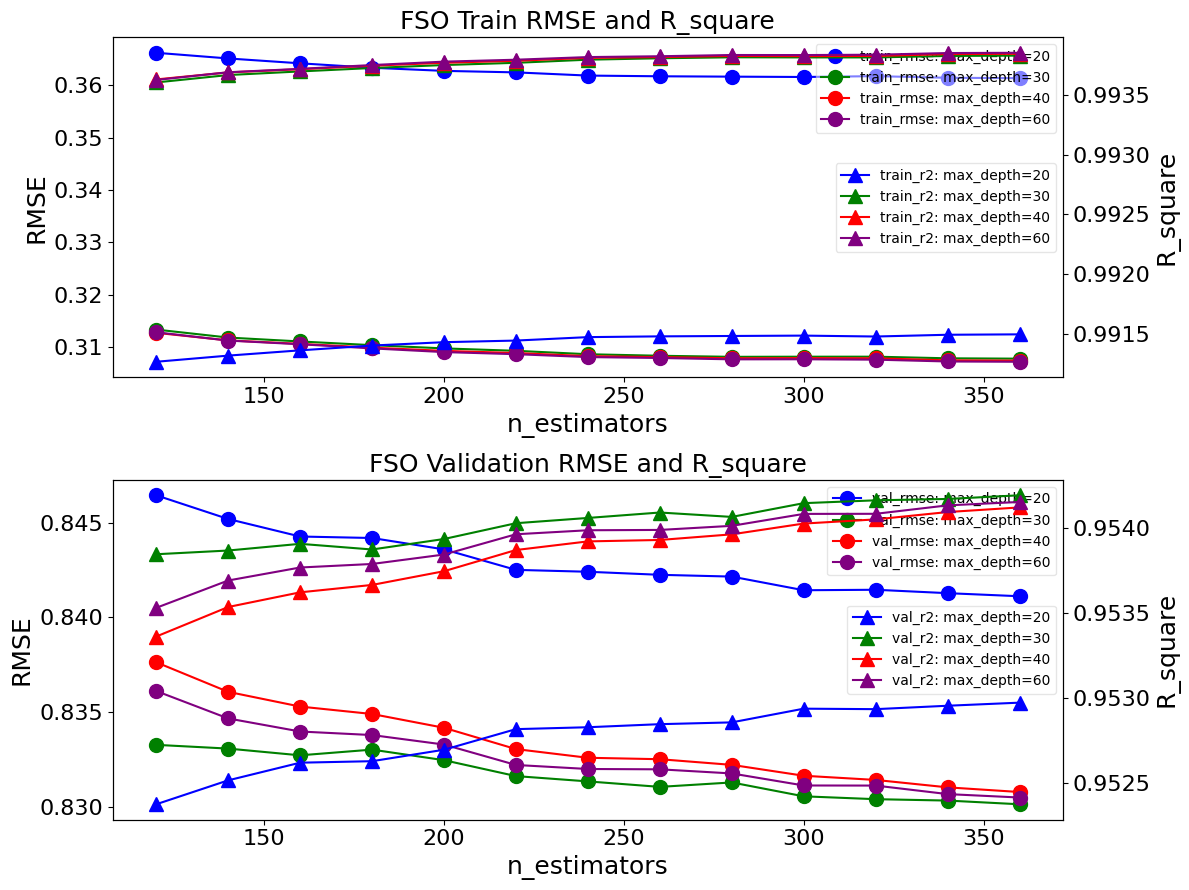

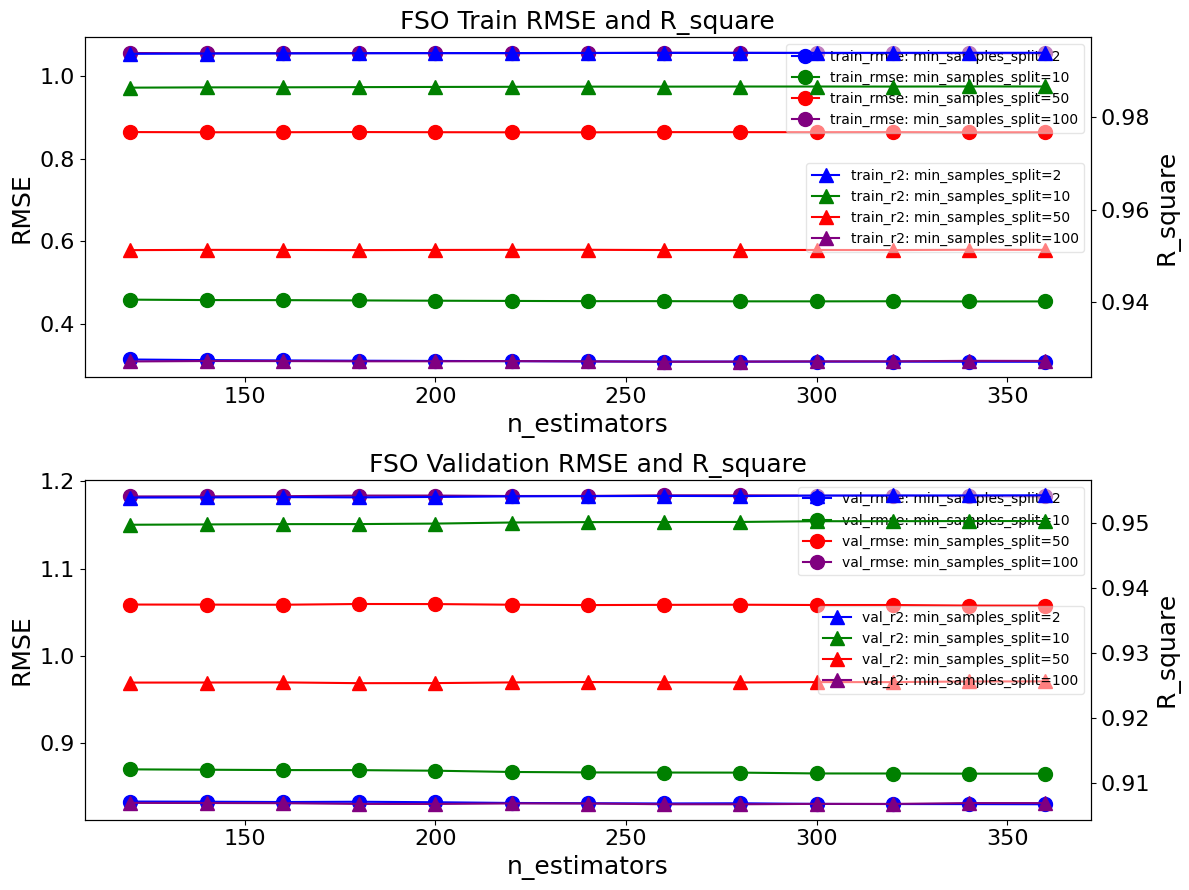

In [ ]:
df = pd.read_csv("results_202402290225_n_estimators-120-360-13_max_depth-20-60-5_min_samples_leaf-1-1-1_min_samples_split-2-100-4_RF_rebuilt_FSO.csv")
print(df)
min_train_mse_row = df[df['train_mse'] == df['train_mse'].min()]
print("train_mse best:")
print(min_train_mse_row)

min_valid_mse_row = df[df['val_mse'] == df['val_mse'].min()]
print("valid_mse best:")
print(min_valid_mse_row)

select_esti = df[(df['min_samples_leaf'] == 1) & (df['min_samples_split'] == 2)]

ModelFunctions.plot_fine_tuning(select_esti, channel = 'FSO', lis=[20,30,40,60], group_column='max_depth', Xaxis='n_estimators',\
                            metrics='RMSE', metrics1='R_square',markersize = 10,\
                            legend_loc="upper right",legend_loc1="right")
# select_esti = df[(df['min_samples_leaf'] == 2) & (df['min_samples_split'] == 3)]

# ModelFunctions.plot_fine_tuning(select_esti, channel = 'FSO', lis=[28,30,32], group_column='max_depth', Xaxis='n_estimators',\
#                             metrics='RMSE', metrics1='R_square',markersize = 10,\
#                             legend_loc="upper right",legend_loc1="right")

select_esti = df[(df['max_depth'] == 30) & (df['min_samples_leaf'] == 1)]

ModelFunctions.plot_fine_tuning(select_esti, channel = 'FSO',lis=[2,10,50,100], group_column='min_samples_split', Xaxis='n_estimators',\
                            metrics='RMSE', metrics1='R_square',markersize = 10,\
                            legend_loc="upper right",legend_loc1="right")

In [ ]:
parameters = {
    'n_estimators': [*range(60,111,10)],
    'max_depth': [*range(27,36,2)],
    'min_samples_leaf': [1],
    'min_samples_split': [2]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_fso, 
                            Ytrain_fso, 
                            Xval_fso, 
                            Yval_fso,
                            n_jobs = 6)
file_name_results = ModelFunctions.save_model_results(results, parameters, file_model="_RF_rebuilt", file_att="_FSO")

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
train Best parameters: {'max_depth': 35, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 110}
train Best score: 0.09846578348126692
valid Best parameters: {'max_depth': 29, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 110}
valid Best score: 0.6994819083296488
Results saved to results_202402290922_n_estimators-60-110-6_max_depth-27-35-5_min_samples_leaf-1-1-1_min_samples_split-2-2-1_RF_rebuilt_80%_FSO.csv


    n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
0             60         27                 1                  2   0.104959   
1             70         27                 1                  2   0.103368   
2             80         27                 1                  2   0.102305   
3             90         27                 1                  2   0.101395   
4            100         27                 1                  2   0.100473   
5            110         27                 1                  2   0.099826   
6             60         29                 1                  2   0.104160   
7             70         29                 1                  2   0.102603   
8             80         29                 1                  2   0.101529   
9             90         29                 1                  2   0.100655   
10           100         29                 1                  2   0.099821   
11           110         29                 1       

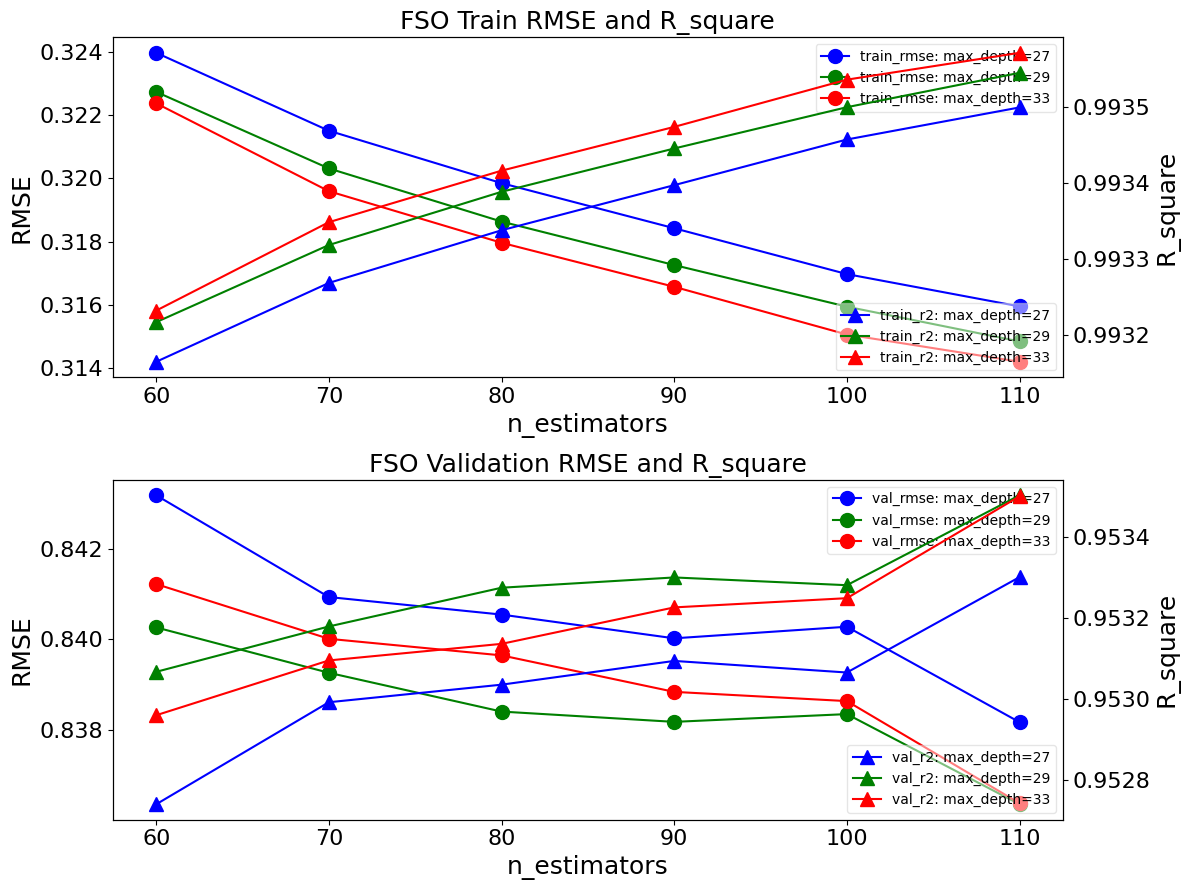

In [ ]:
df = pd.read_csv("results_202402290922_n_estimators-60-110-6_max_depth-27-35-5_min_samples_leaf-1-1-1_min_samples_split-2-2-1_RF_rebuilt_FSO.csv")
print(df)

min_train_mse_row = df[df['train_mse'] == df['train_mse'].min()]
print("train_mse best:")
print(min_train_mse_row)

min_valid_mse_row = df[df['val_mse'] == df['val_mse'].min()]
print("valid_mse best:")
print(min_valid_mse_row)

select_esti = df[(df['min_samples_leaf'] == 1) & (df['min_samples_split'] == 2)]

ModelFunctions.plot_fine_tuning(select_esti, channel = 'FSO', lis=[27,29,33], group_column='max_depth', Xaxis='n_estimators',\
                            metrics='RMSE', metrics1='R_square',markersize = 10,\
                            legend_loc="upper right",legend_loc1="lower right")

# select_esti = df[(df['max_depth'] == 29) & (df['min_samples_split'] == 3)]

# ModelFunctions.plot_fine_tuning(select_esti, channel = 'FSO',lis=[1,2,3,4], group_column='min_samples_leaf', Xaxis='n_estimators',\
#                             metrics='RMSE', metrics1='R_square',markersize = 10,\
#                             legend_loc="upper right",legend_loc1="right")

In [ ]:
parameters = {
    'n_estimators': [*range(60,201,20)],
    'max_depth': [*range(20,41,10)],
    'min_samples_leaf': [1],
    'min_samples_split': [2,10,50]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_rfl, 
                            Ytrain_rfl, 
                            Xval_rfl, 
                            Yval_rfl,
                            n_jobs = 6)
file_name_results = ModelFunctions.save_model_results(results, parameters, file_model="_RF_rebuilt", file_att="_RFL")

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
train Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
train Best score: 0.03863239759282747
valid Best parameters: {'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 140}
valid Best score: 0.28324498320021085
Results saved to results_202402291047_n_estimators-60-200-8_max_depth-20-40-3_min_samples_leaf-1-1-1_min_samples_split-2-50-3_RF_rebuilt_RFL.csv


    n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
0             60         20                 1                  2   0.046145   
1             80         20                 1                  2   0.043775   
2            100         20                 1                  2   0.043651   
3            120         20                 1                  2   0.043452   
4            140         20                 1                  2   0.043111   
..           ...        ...               ...                ...        ...   
67           120         40                 1                 50   0.307564   
68           140         40                 1                 50   0.306851   
69           160         40                 1                 50   0.306083   
70           180         40                 1                 50   0.306587   
71           200         40                 1                 50   0.306801   

    train_r2   val_mse    val_r2  
0   0.996111  0.

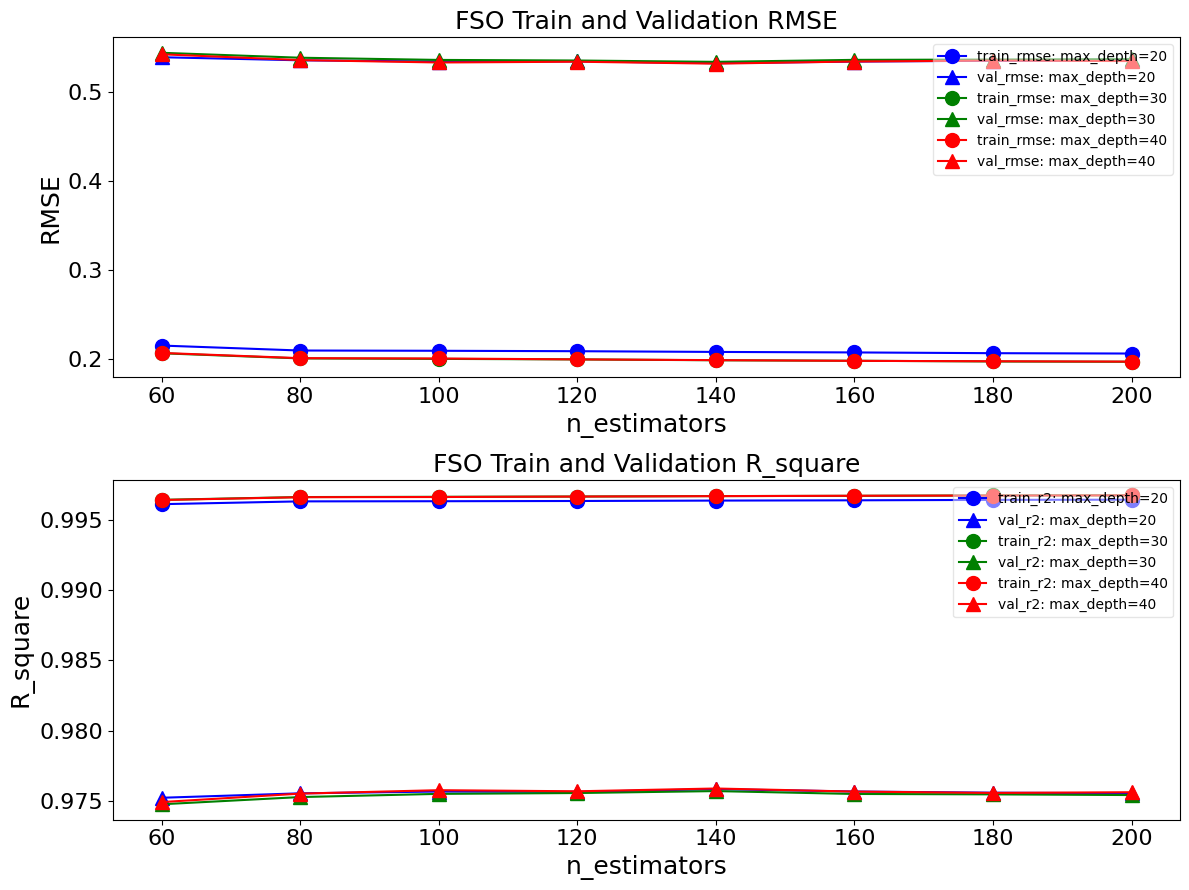

In [ ]:
df = pd.read_csv("results_202402291047_n_estimators-60-200-8_max_depth-20-40-3_min_samples_leaf-1-1-1_min_samples_split-2-50-3_RF_rebuilt_RFL.csv")
print(df)

min_train_mse_row = df[df['train_mse'] == df['train_mse'].min()]
print("train_mse best:")
print(min_train_mse_row)

min_valid_mse_row = df[df['val_mse'] == df['val_mse'].min()]
print("valid_mse best:")
print(min_valid_mse_row)

select_esti = df[(df['min_samples_leaf'] == 1) & (df['min_samples_split'] == 2)]

ModelFunctions.plot_coarse_tuning(select_esti, channel = "FSO", group_column='max_depth', Xaxis='n_estimators',
                        metrics='RMSE', metrics1='R_square', legend_loc="upper right",\
                            markersize = 10)

# select_esti = df[(df['max_depth'] == 29) & (df['min_samples_split'] == 3)]

# ModelFunctions.plot_fine_tuning(select_esti, channel = 'FSO',lis=[1,2,3,4], group_column='min_samples_leaf', Xaxis='n_estimators',\
#                             metrics='RMSE', metrics1='R_square',markersize = 10,\
#                             legend_loc="upper right",legend_loc1="right")

In [ ]:
parameters = {
    'n_estimators': [*range(70,91,5)],
    'max_depth': [*range(25,34,2)],
    'min_samples_leaf': [1],
    'min_samples_split': [2]
}

results = ModelFunctions.rf_evaluate_parameter_grid(parameters, 
                            Xtrain_rfl, 
                            Ytrain_rfl, 
                            Xval_rfl, 
                            Yval_rfl,
                            n_jobs = 6)
file_name_results = ModelFunctions.save_model_results(results, parameters, file_model="_RF_rebuilt", file_att="_RFL")

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
train Best parameters: {'max_depth': 27, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 80}
train Best score: 0.040282317597764836
valid Best parameters: {'max_depth': 27, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 80}
valid Best score: 0.2832324321189421
Results saved to results_202402291119_n_estimators-70-90-5_max_depth-25-33-5_min_samples_leaf-1-1-1_min_samples_split-2-2-1_RF_rebuilt_RFL.csv


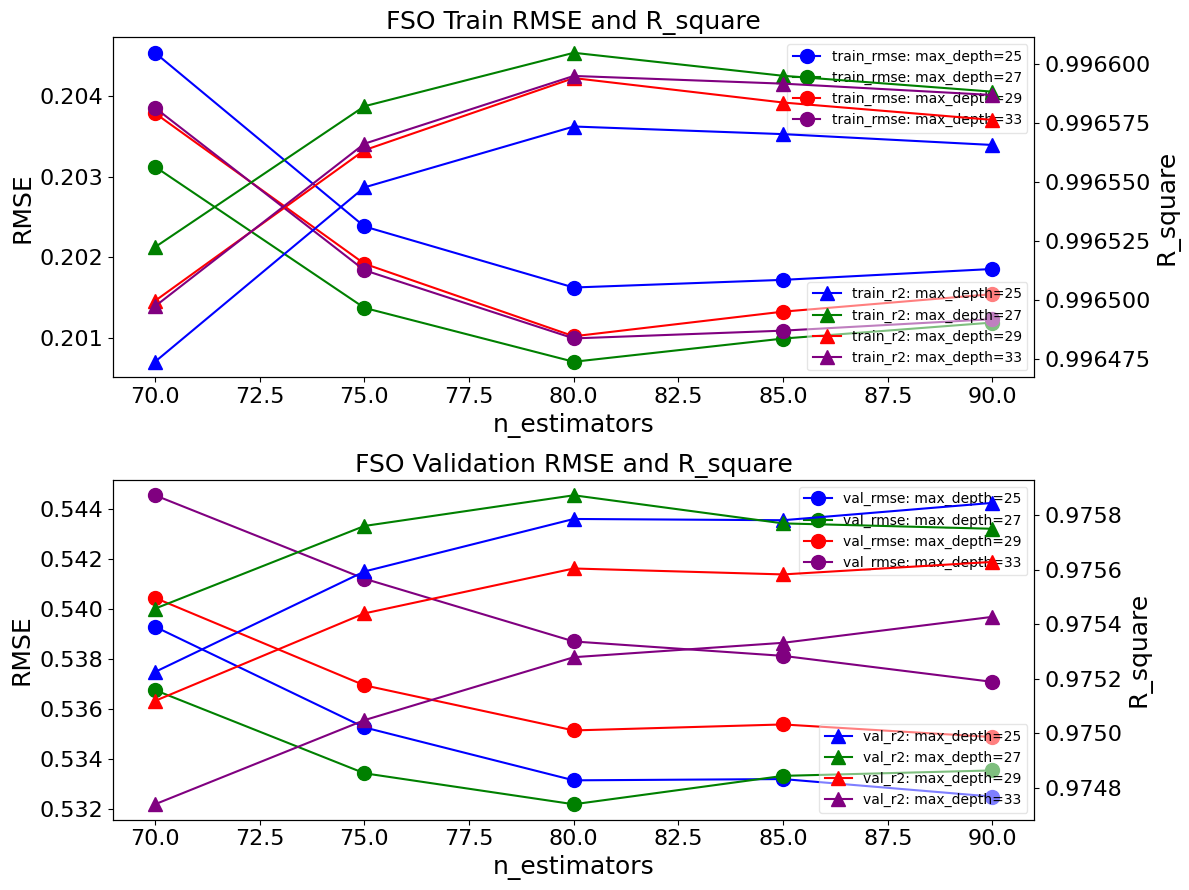

In [ ]:
df = pd.read_csv("results_202402291119_n_estimators-70-90-5_max_depth-25-33-5_min_samples_leaf-1-1-1_min_samples_split-2-2-1_RF_rebuilt_RFL.csv")

select_esti = df[(df['min_samples_leaf'] == 1) & (df['min_samples_split'] == 2)]

ModelFunctions.plot_fine_tuning(select_esti, channel = 'FSO', lis=[25,27,29,33], group_column='max_depth', Xaxis='n_estimators',\
                            metrics='RMSE', metrics1='R_square',markersize = 10,\
                            legend_loc="upper right",legend_loc1="lower right")